## Exploratory Data Analysis (EDA)

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [46]:
df=pd.read_csv('/content/Indian Road Accident (2022–2025) EDA.csv')

In [47]:
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,22-10-2023,05:00,5,Sunday,1,...,fog,low,32,high,weather,fatal,2,2,0,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,21-05-2023,04:00,4,Sunday,1,...,clear,high,34,low,weather,major,4,3,0,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,10-07-2024,13:00,13,Wednesday,0,...,fog,low,21,medium,weather,minor,1,1,0,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,30-03-2025,11:00,11,Sunday,1,...,fog,low,30,high,distraction,minor,5,2,0,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,25-01-2024,16:00,16,Thursday,0,...,clear,high,24,low,distraction,minor,2,1,0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,29-09-2022,03:00,3,Thursday,0,...,clear,high,31,low,distraction,minor,3,2,0,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,25-11-2023,01:00,1,Saturday,1,...,clear,high,20,low,distraction,major,4,2,0,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,18-06-2022,15:00,15,Saturday,1,...,clear,high,22,low,weather,minor,3,3,0,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,12-03-2023,04:00,4,Sunday,1,...,clear,high,33,low,poor road,minor,1,0,0,0.10


In [48]:
# Display to N Rows
df.head()


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,22-10-2023,05:00,5,Sunday,1,...,fog,low,32,high,weather,fatal,2,2,0,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,21-05-2023,04:00,4,Sunday,1,...,clear,high,34,low,weather,major,4,3,0,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,10-07-2024,13:00,13,Wednesday,0,...,fog,low,21,medium,weather,minor,1,1,0,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,30-03-2025,11:00,11,Sunday,1,...,fog,low,30,high,distraction,minor,5,2,0,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,25-01-2024,16:00,16,Thursday,0,...,clear,high,24,low,distraction,minor,2,1,0,0.10


In [49]:
# Display bottom N rows
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,29-09-2022,03:00,3,Thursday,0,...,clear,high,31,low,distraction,minor,3,2,0,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,25-11-2023,01:00,1,Saturday,1,...,clear,high,20,low,distraction,major,4,2,0,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,18-06-2022,15:00,15,Saturday,1,...,clear,high,22,low,weather,minor,3,3,0,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,12-03-2023,04:00,4,Sunday,1,...,clear,high,33,low,poor road,minor,1,0,0,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,05-07-2024,23:00,23,Friday,0,...,rain,low,39,high,overspeeding,minor,4,2,0,0.65


In [50]:
# Number of columns and rows
print(f"The DataFrame is having {df.shape[0]} rows and {df.shape[1]} columns")

The DataFrame is having 20000 rows and 23 columns


In [51]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'risk_score'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [53]:
# Data Columm is having dtype as object and we need to convert it into date
df['date']=pd.to_datetime(df['date'],format="%d-%m-%Y")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   accident_id        20000 non-null  int64         
 1   city               20000 non-null  object        
 2   state              20000 non-null  object        
 3   latitude           20000 non-null  float64       
 4   longitude          20000 non-null  float64       
 5   date               20000 non-null  datetime64[ns]
 6   time               20000 non-null  object        
 7   hour               20000 non-null  int64         
 8   day_of_week        20000 non-null  object        
 9   is_weekend         20000 non-null  int64         
 10  road_type          20000 non-null  object        
 11  lanes              20000 non-null  int64         
 12  traffic_signal     20000 non-null  int64         
 13  weather            20000 non-null  object        
 14  visibi

In [54]:
# Missing Values
df.isnull().sum()

,0
accident_id,0
city,0
state,0
latitude,0
longitude,0
date,0
time,0
hour,0
day_of_week,0
is_weekend,0


In [55]:
# Duplicate  values
df.duplicated().sum()

np.int64(0)

In [56]:
# EXtracting Year, Month , Day from Date Column
df['Year']=df['date'].dt.year
df['Month_Name']=df['date'].dt.month_name()
df['Day_Name']=df['date'].dt.day_name()

In [57]:
df['accident_severity'].value_counts()

,count
accident_severity,
minor,11025
major,5988
fatal,2987


In [58]:
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,risk_score,Year,Month_Name,Day_Name
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,05:00,5,Sunday,1,...,high,weather,fatal,2,2,0,0.85,2023,October,Sunday
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,04:00,4,Sunday,1,...,low,weather,major,4,3,0,0.10,2023,May,Sunday
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,medium,weather,minor,1,1,0,0.45,2024,July,Wednesday
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,high,distraction,minor,5,2,0,0.65,2025,March,Sunday
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,low,distraction,minor,2,1,0,0.10,2024,January,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,03:00,3,Thursday,0,...,low,distraction,minor,3,2,0,0.10,2022,September,Thursday
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,01:00,1,Saturday,1,...,low,distraction,major,4,2,0,0.10,2023,November,Saturday
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,low,weather,minor,3,3,0,0.10,2022,June,Saturday
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,04:00,4,Sunday,1,...,low,poor road,minor,1,0,0,0.10,2023,March,Sunday


# Create function to find outliers and apply the function on a DataFrame

In [59]:
from numpy._core.defchararray import lower
def Outliers(data,col):
  q1=data[col].quantile(0.25)
  q3=data[col].quantile(0.75)
  IQR=q3-q1
  lower_fence=q1-1.5*(IQR)
  upper_fence=q3+1.5*(IQR)
  Outliers=data[(data[col]<lower_fence)|(data[col]>upper_fence)]
  return lower_fence,upper_fence,Outliers

In [60]:
col=['vehicles_involved','casualties','traffic_signal']
for cl in col:
  lf,uf,outlr=Outliers(df,cl)
  print(f"\nColumn:{cl}")
  print("Lower Fence:",lf)
  print("Upper Fence:",uf)
  print("Count of Outliers:",outlr.shape[0])


Column:vehicles_involved
Lower Fence: -1.0
Upper Fence: 7.0
Count of Outliers: 0

Column:casualties
Lower Fence: -2.0
Upper Fence: 6.0
Count of Outliers: 0

Column:traffic_signal
Lower Fence: -1.5
Upper Fence: 2.5
Count of Outliers: 0


# Graph 1: Accident Severity Distribution

This bar chart shows the frequency of each accident severity level.




/tmp/ipykernel_1854/2115018374.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


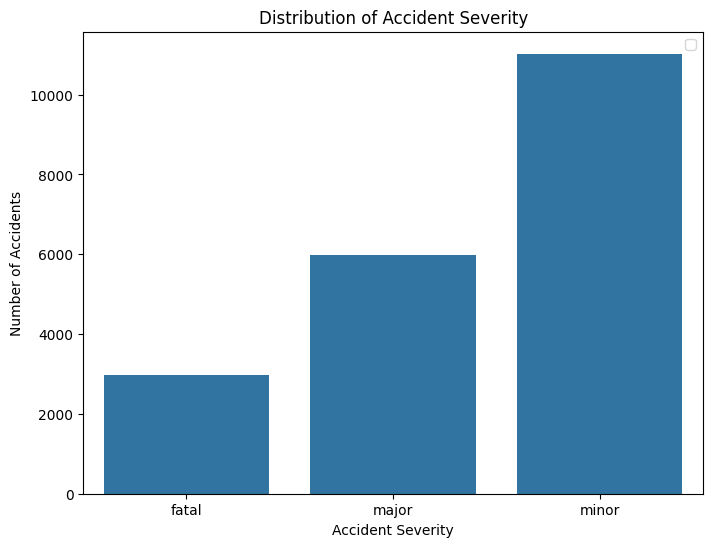

In [61]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='accident_severity')
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')
plt.legend()
plt.show()

### Graph 2:  State-wise Accidents

The State-wise Accidents chart shows which states have the highest number of accident records in your dataset.



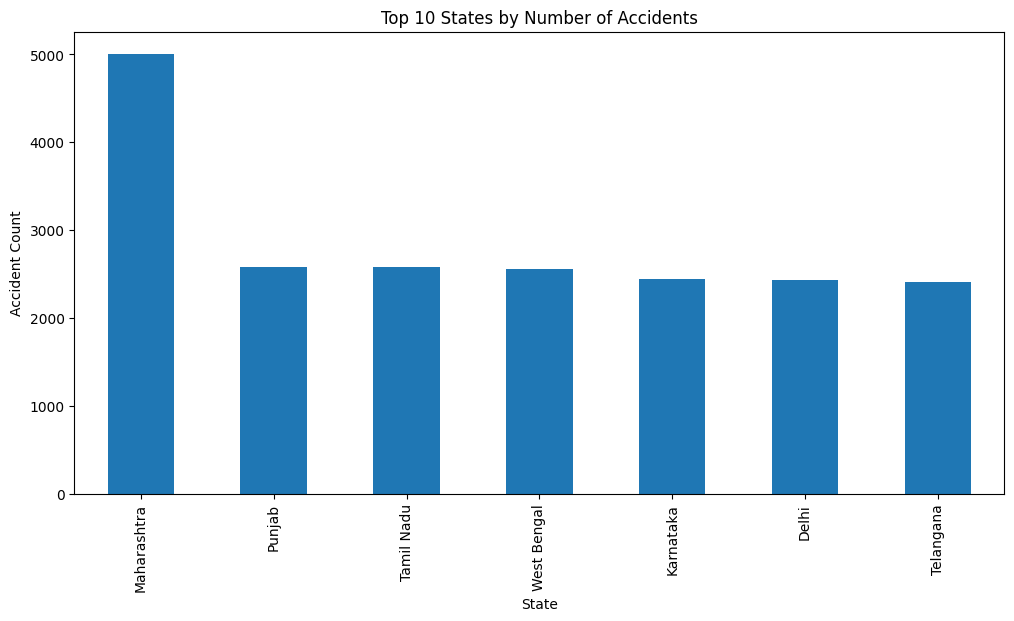

In [62]:
plt.figure(figsize=(12,6))
df['state'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")
plt.show()

### Graph 3: Peak Hour Analysis

This chart shows whether accidents occurred during peak traffic hours or non-peak hours.



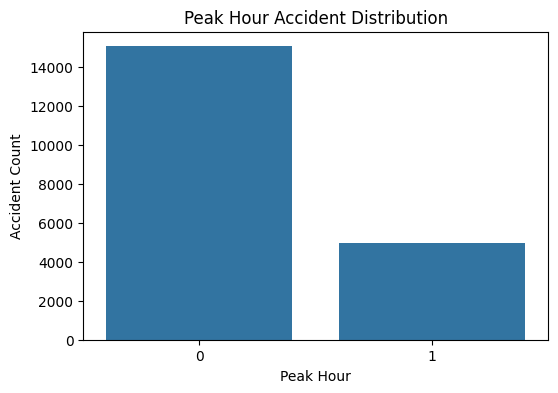

In [63]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='is_peak_hour',
    data=df
)

plt.title("Peak Hour Accident Distribution")
plt.xlabel("Peak Hour")
plt.ylabel("Accident Count")
plt.show()

## Graph 4: Risk Score Distributions
The Risk Score Distribution chart shows how accident records are spread across different risk score values

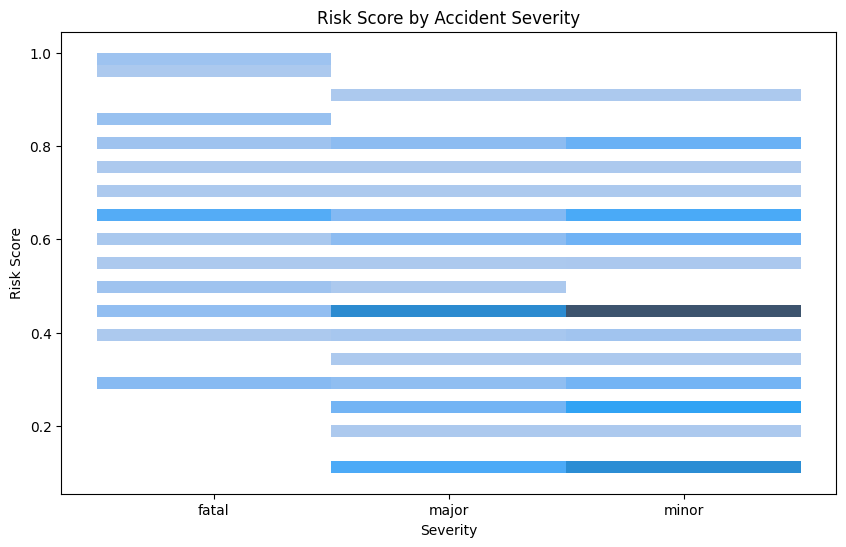

In [77]:

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='accident_severity',
    y='risk_score'
)

plt.title('Risk Score by Accident Severity')
plt.xlabel('Severity')
plt.ylabel('Risk Score')
plt.show()

### Graph 5: Severity vs Weather

This chart shows the relationship between Weather Condition and Accident Severity.

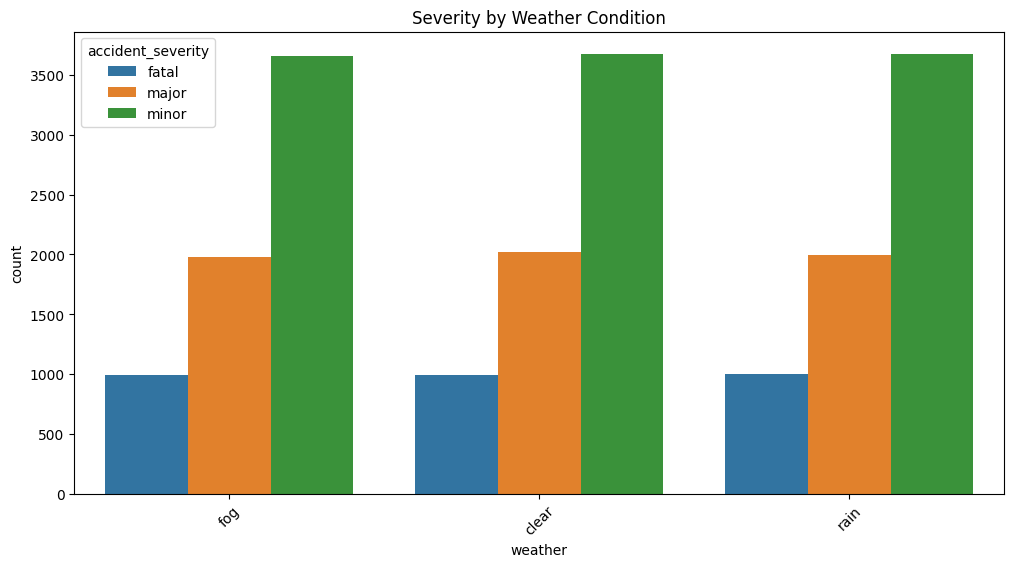

In [44]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='weather',
    hue='accident_severity',
    data=df
)

plt.xticks(rotation=45)
plt.title("Severity by Weather Condition")
plt.show()

## Graph 6: Severity vs Road Type

This chart shows how accident severity (Minor, Major, Fatal) varies across different road types.

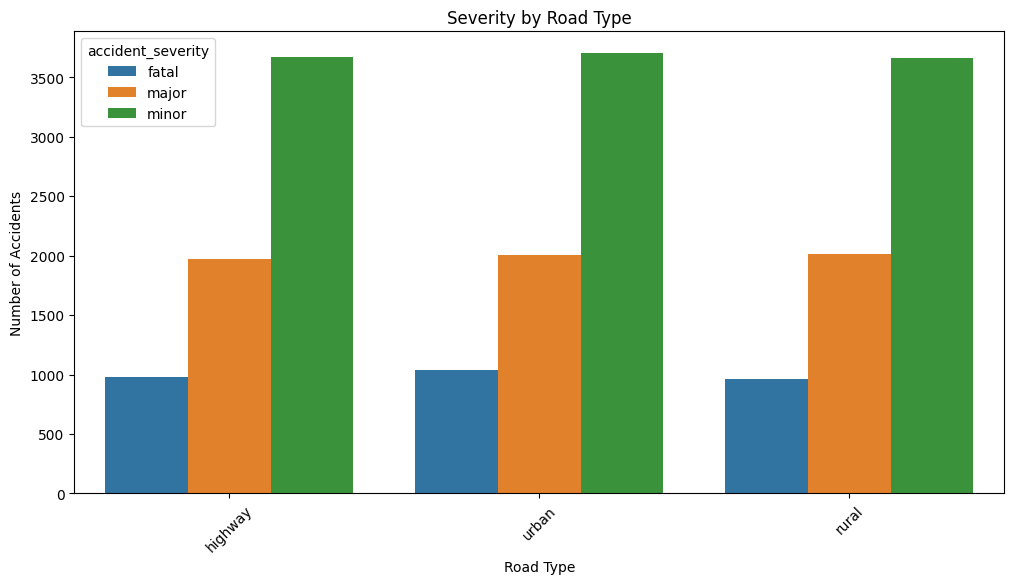

In [64]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='road_type',
    hue='accident_severity',
    data=df
)

plt.xticks(rotation=45)
plt.title("Severity by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Number of Accidents")
plt.show()

## Graph 7: Correlation Heatmap

A Correlation Heatmap shows the strength of the relationship between numerical variables in your dataset.

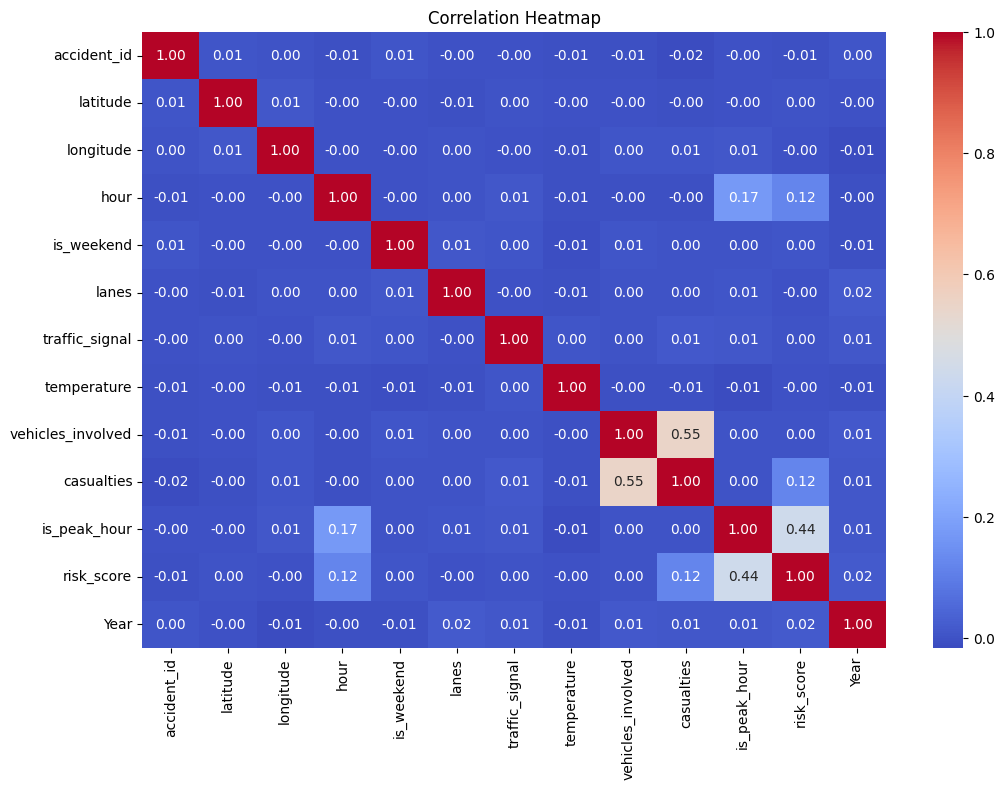

In [65]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

##  Graph 8: Top Cities

The Top Cities chart shows which cities have the highest number of accident records in the dataset.


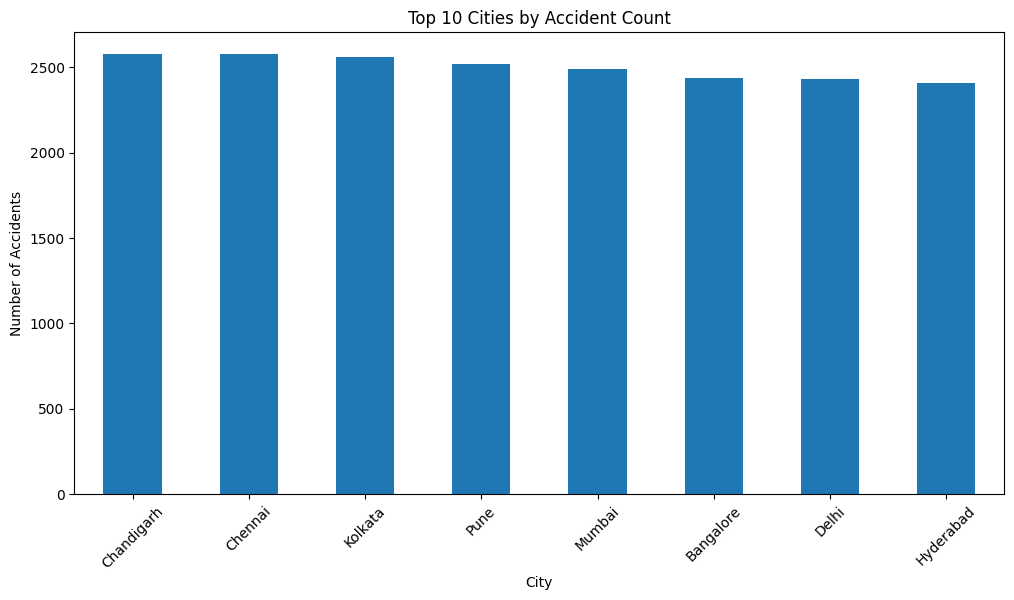

In [66]:
plt.figure(figsize=(12,6))

df['city'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Cities by Accident Count")
plt.xlabel("City")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

## Graph 9: Risk Score by Severity

This chart shows how Risk Scores vary across different Accident Severity categories.

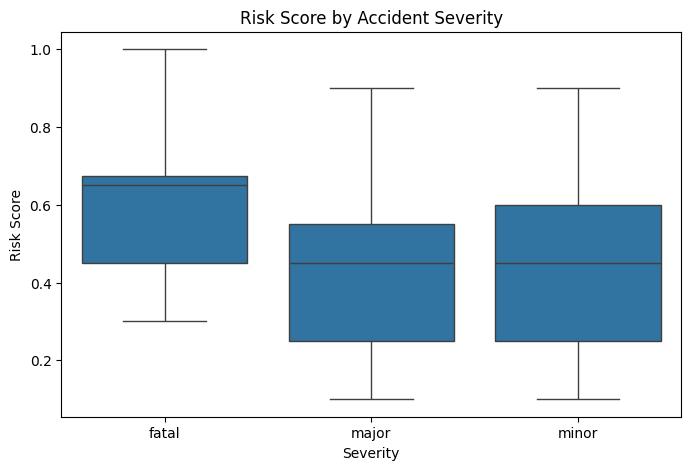

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='accident_severity',
    y='risk_score',
    data=df
)

plt.title("Risk Score by Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Risk Score")
plt.show()

## Key Insights

In [68]:
print("\nTop States:")
print(df['state'].value_counts().head())


Top States:
state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Name: count, dtype: int64


In [69]:
print("\nAverage Risk Score:")
print(df['risk_score'].mean())


Average Risk Score:
0.43758500000000006


In [70]:

print("\nAverage Casualties:")
print(df['casualties'].mean())


Average Casualties:
1.72645


In [71]:
print("\nAverage Vehicles Involved:")
print(df['vehicles_involved'].mean())


Average Vehicles Involved:
2.992
